# 📊 Descrição das Colunas - Dataset de Cogumelos
# João Victor Donadio - 4201058

- **id**: identificador único de cada registro (int64)  
- **class**: indica se o cogumelo é comestível (e) ou venenoso (p) (object)  
- **cap-diameter**: diâmetro do chapéu do cogumelo (float64)  
- **cap-shape**: formato do chapéu (valores categóricos codificados) (object)  
- **cap-surface**: tipo de superfície do chapéu (object)  
- **cap-color**: cor do chapéu (object)  
- **does-bruise-or-bleed**: indica se o cogumelo muda de cor ao ser danificado (object)  
- **gill-attachment**: forma de fixação das lamelas ao caule (object)  
- **gill-spacing**: espaçamento entre as lamelas (object)  
- **gill-color**: cor das lamelas (object)  
- **stem-height**: altura do caule (float64)  
- **stem-width**: largura do caule (float64)  
- **stem-root**: tipo de raiz do caule (object)  
- **stem-surface**: tipo de superfície do caule (object)  
- **stem-color**: cor do caule (object)  
- **veil-type**: tipo de véu do cogumelo (object)  
- **veil-color**: cor do véu (object)  
- **has-ring**: indica se o cogumelo possui anel no caule (object)  
- **ring-type**: tipo de anel presente no caule (object)  
- **spore-print-color**: cor da impressão de esporos (pode conter valores nulos) (object)  
- **habitat**: ambiente onde o cogumelo cresce (object)  
- **season**: estação do ano em que o cogumelo aparece (object)  

# Data Preparation Pipeline for Machine Learning
## Case Study: Mushroom Dataset

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados
3. Encoding de Variáveis Categóricas
4. Seleção de Features
5. Split do Dataset e Balanceamento


In [8]:
# Celula 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif

from imblearn.over_sampling import SMOTE


# Carregar Dataset

In [9]:
# Celula 02
df = pd.read_csv('/home/joaov/github/machine-learning-mushroom/notebooks/mushroom/train.csv')
df.head(6)

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a
5,5,p,4.30,x,t,n,f,s,c,n,...,NaN,NaN,w,NaN,n,t,z,NaN,d,a


# 1. Análise Exploratória (EDA)

**Observação:**
Para iniciarmos nossa Análise Exploratória de Dados (EDA), o primeiro passo é sempre entender a estrutura dos dados que temos em mãos.

A função `df.info()` nos fornece um resumo sobre o tamanho do dataset, os tipos de dados de cada coluna e, importantíssimo, a quantidade de valores não-nulos. Ao analisar o retorno dessa função, podemos observar evidências claras de problemas (nulos) em algumas colunas específicas do dataset de cogumelos.

In [10]:
# Celula 03
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048574 non-null  float64
 3   cap-shape             1048558 non-null  str    
 4   cap-surface           822881 non-null   str    
 5   cap-color             1048572 non-null  str    
 6   does-bruise-or-bleed  1048573 non-null  str    
 7   gill-attachment       872245 non-null   str    
 8   gill-spacing          626042 non-null   str    
 9   gill-color            1048557 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             121188 non-null   str    
 13  stem-surface          382035 non-null   str    
 14  stem-color            1048563 non-null  str  

**Dicionário de Dados (Significado das Features):**

*   **`0. id`**: identificador único de cada registro (int64)  
*   **`1. class`**: indica se o cogumelo é comestível (e) ou venenoso (p) (object) - nossa variável alvo  
*   **`2. cap-diameter`**: diâmetro do chapéu do cogumelo (float64)  
*   **`3. cap-shape`**: formato do chapéu (valores categóricos codificados) (object)  
*   **`4. cap-surface`**: tipo de superfície do chapéu (object)  
*   **`5. cap-color`**: cor do chapéu (object)  
*   **`6. does-bruise-or-bleed`**: indica se o cogumelo muda de cor ao ser danificado (object)  
*   **`7. gill-attachment`**: forma de fixação das lamelas ao caule (object)  
*   **`8. gill-spacing`**: espaçamento entre as lamelas (object)  
*   **`9. gill-color`**: cor das lamelas (object)  
*   **`10. stem-height`**: altura do caule (float64)  
*   **`11. stem-width`**: largura do caule (float64)  
*   **`12. stem-root`**: tipo de raiz do caule (object)  
*   **`13. stem-surface`**: tipo de superfície do caule (object)  
*   **`14. stem-color`**: cor do caule (object)  
*   **`15. veil-type`**: tipo de véu do cogumelo (object)  
*   **`16. veil-color`**: cor do véu (object)  
*   **`17. has-ring`**: indica se o cogumelo possui anel no caule (object)  
*   **`18. ring-type`**: tipo de anel presente no caule (object)  
*   **`19. spore-print-color`**: cor da impressão de esporos (pode conter valores nulos) (object)  
*   **`20. habitat`**: ambiente onde o cogumelo cresce (object)  
*   **`21. season`**: estação do ano em que o cogumelo aparece (object)

**Observação:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.describe()` gera um sumário estatístico (média, desvio padrão, quartis, valores mínimos e máximos) das colunas numéricas, o que nos ajuda a identificar logo de cara possíveis anomalias numéricas.

In [11]:
# Celula 04
df.describe()

,id,cap-diameter,stem-height,stem-width
count,1.048575e+06,1.048574e+06,1.048575e+06,1.048575e+06
mean,5.242870e+05,6.308374e+00,6.348367e+00,1.115505e+01
std,3.026977e+05,4.648956e+00,2.698178e+00,8.103385e+00
min,0.000000e+00,4.000000e-01,0.000000e+00,0.000000e+00
25%,2.621435e+05,3.320000e+00,4.680000e+00,4.970000e+00
50%,5.242870e+05,5.750000e+00,5.880000e+00,9.650000e+00
75%,7.864305e+05,8.240000e+00,7.410000e+00,1.563000e+01
max,1.048574e+06,8.067000e+01,8.872000e+01,1.029000e+02


**Observação:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.isnull().sum()` nos permite totalizar em números absolutos a quantidade de dados faltantes para podermos traçar um plano de ação (imputar dados ou descartar a coluna).

In [12]:
# Celula 05
df.isnull().sum()

id                           0
class                        0
cap-diameter                 1
cap-shape                   17
cap-surface             225694
cap-color                    3
does-bruise-or-bleed         2
gill-attachment         176330
gill-spacing            422533
gill-color                  18
stem-height                  0
stem-width                   0
stem-root               927387
stem-surface            666540
stem-color                  12
veil-type               995051
veil-color              922192
has-ring                     7
ring-type                43214
spore-print-color       958822
habitat                     18
season                       0
dtype: int64

# Visualização

**Observação:**
Aqui nós plotamos os histogramas de todas as features numéricas do dataframe. A análise visual é crucial! Reparem no formato das distributions.

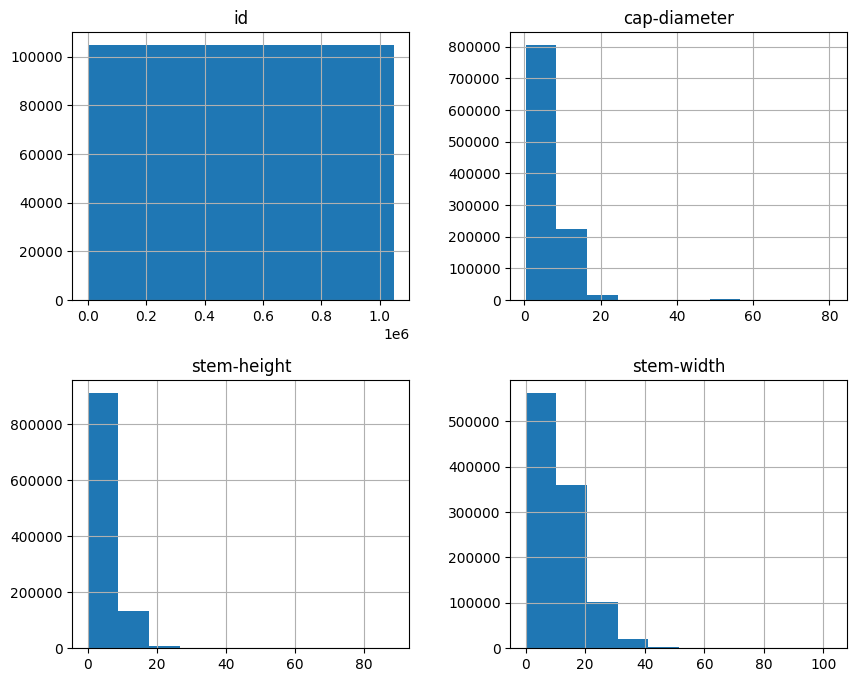

In [13]:
df.hist(figsize=(10,8))
plt.show()

# 2. Limpeza de Dados
- 'cap-diameter', 'stem-height' e 'stem-width' são as únicas features numéricas contínuas no seu dataset. Temos que tomar cuidado com os dados numéricos contínuos.

- Por exemplo, diâmetros de 1000 unidades podem ser interpretadas como erros de digitação e podem ser substituídas pela média ou mediana.

- Porém, diâmetros como 0 e 50 que são considerados válidos, podem invalidar a predição do algoritmo de ML que dependem de cálculos de distância como o KNN ou SVM. Temos também os algoritmos de otimização baseada em gradientes como a Regressão Logística. 

- Todos esses 3 algoritmos seriam impactados pela distância numérica entre esses dados. Por exemplo, imagine uma feature booleana.

- Os valores 0 e 1 possuem uma distância de 1, já na feature cap-diameter, podemos ter distâncias muito grandes (50 - 0). 

- Cabe ao cientista reduzir a distância desses dados antes de aplicar um destes algoritmos de ML citados.

**Observação:**
Nesta etapa de limpeza, começamos removendo as linhas duplicadas para evitar viés no modelo. Em seguida, realizamos a imputação dos valores nulos: para as colunas numéricas, utilizamos a mediana, que se mostra mais robusta contra valores extremos (outliers) do que a média; para categóricas, usamos a moda (valor mais frequente). Por fim, removemos colunas com muitos valores nulos se necessário.

In [14]:
# Celula 06 - Observe que algumas colunas possuem valores nulos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048574 non-null  float64
 3   cap-shape             1048558 non-null  str    
 4   cap-surface           822881 non-null   str    
 5   cap-color             1048572 non-null  str    
 6   does-bruise-or-bleed  1048573 non-null  str    
 7   gill-attachment       872245 non-null   str    
 8   gill-spacing          626042 non-null   str    
 9   gill-color            1048557 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             121188 non-null   str    
 13  stem-surface          382035 non-null   str    
 14  stem-color            1048563 non-null  str  

In [15]:
# Celula 07 - Remove linhas duplicadas
df = df.drop_duplicates() # Elimina linhas duplicadas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048574 non-null  float64
 3   cap-shape             1048558 non-null  str    
 4   cap-surface           822881 non-null   str    
 5   cap-color             1048572 non-null  str    
 6   does-bruise-or-bleed  1048573 non-null  str    
 7   gill-attachment       872245 non-null   str    
 8   gill-spacing          626042 non-null   str    
 9   gill-color            1048557 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             121188 non-null   str    
 13  stem-surface          382035 non-null   str    
 14  stem-color            1048563 non-null  str  

In [16]:
# Celula 08 - Imputar valores nulos
# Para numéricas: mediana
df['cap-diameter'] = df['cap-diameter'].fillna(df['cap-diameter'].median())
df['stem-height'] = df['stem-height'].fillna(df['stem-height'].median())
df['stem-width'] = df['stem-width'].fillna(df['stem-width'].median())

# Para categóricas: moda
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'class':  # Não imputar a target
        df[col] = df[col].fillna(df[col].mode()[0])

# Dropar colunas com muitos nulos se necessário (ex: veil-type se tiver muitos)

/tmp/ipykernel_12648/2341065367.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048575 non-null  float64
 3   cap-shape             1048575 non-null  str    
 4   cap-surface           1048575 non-null  str    
 5   cap-color             1048575 non-null  str    
 6   does-bruise-or-bleed  1048575 non-null  str    
 7   gill-attachment       1048575 non-null  str    
 8   gill-spacing          1048575 non-null  str    
 9   gill-color            1048575 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             1048575 non-null  str    
 13  stem-surface          1048575 non-null  str    
 14  stem-color            1048575 non-null  str  

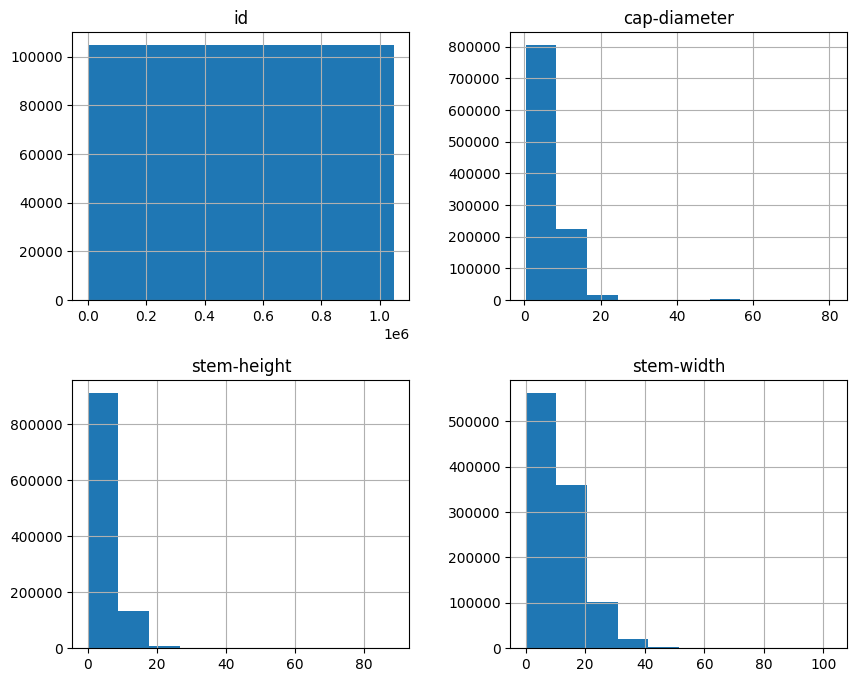

In [17]:
# Celula 09 - Verificar após limpeza
df.info()

df.hist(figsize=(10,8))
plt.show()

**Observação - Por que Moda e Mediana?**

O motivo de usarmos medidas estatísticas diferentes se deve à natureza dos dados (o tipo da variável) de cada coluna.

Em Ciência de Dados, a forma como tratamos os números é diferente da forma como tratamos categorias (textos). Vamos entender cada caso:

**1. Variáveis Categóricas (ex: cap-shape, habitat) = Variável Categórica**
Essas colunas contêm texto ou categorias.

- **Por que a Moda?** A moda representa o valor que mais se repete. Como não é possível calcular a média ou a mediana de textos, a moda é a única medida de tendência central aplicável a dados categóricos.

**2. Variáveis Numéricas (ex: cap-diameter, stem-height) = Variável Numérica (Contínua)**
Essas colunas contêm números.

- **Por que a Mediana e não a Média?** A média é muito sensível a outliers. Se houver valores extremos, a média será distorcida. A mediana, por ser o valor do meio quando ordenado, ignora extremos e dá um retrato mais fiel.

# 3. Encoding

**Observação:**
Para este dataset de cogumelos com várias features de alta cardinalidade, preferimos Target Encoding ou o encoding nativo do CatBoost em vez de One-Hot Encoding. Isso evita a explosão de colunas esparsas e mantém o pipeline leve.


In [18]:
# Celula 16 - Target Encoding / CatBoost-style encoding
categorical_cols = [col for col in df.columns if col not in ['id', 'class', 'cap-diameter', 'stem-height', 'stem-width']]
raw_categorical_cols = categorical_cols.copy()

# O encoding efetivo será feito após o split, usando apenas estatísticas do conjunto de treino para evitar vazamento.


<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   class                 1048575 non-null  str    
 2   cap-diameter          1048575 non-null  float64
 3   cap-shape             1048575 non-null  str    
 4   cap-surface           1048575 non-null  str    
 5   cap-color             1048575 non-null  str    
 6   does-bruise-or-bleed  1048575 non-null  str    
 7   gill-attachment       1048575 non-null  str    
 8   gill-spacing          1048575 non-null  str    
 9   gill-color            1048575 non-null  str    
 10  stem-height           1048575 non-null  float64
 11  stem-width            1048575 non-null  float64
 12  stem-root             1048575 non-null  str    
 13  stem-surface          1048575 non-null  str    
 14  stem-color            1048575 non-null  str  

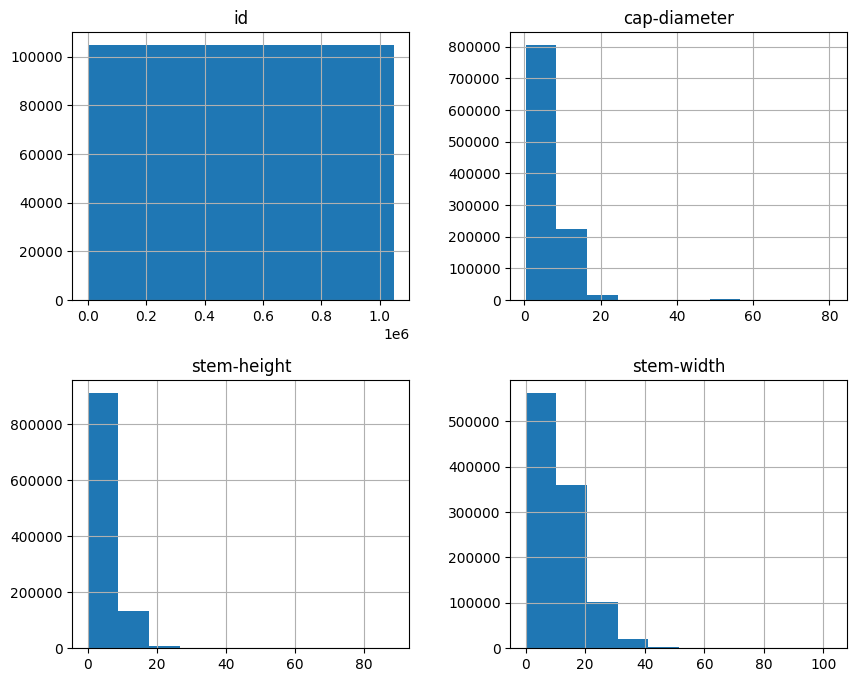

In [19]:
# Celula 17 - Verificar após encoding
df.info()

df.hist(figsize=(10,8))
plt.show()

# 4. Seleção de Features

In [20]:
# Celula 18 - Preparar X e y
# Variável alvo:
df['class'] = df['class'].map({'e': 0, 'p': 1})
y = df['class']

# Seleção manual de 5 features mais importantes com base nas descrições
data_features = [
    'cap-diameter',
    'cap-shape',
    'cap-surface',
    'spore-print-color',
    'habitat'
]
X = df[data_features]
print('Features selecionadas:', data_features)
print('X shape:', X.shape, 'y shape:', y.shape)

Features selecionadas: ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']
X shape: (1048575, 5) y shape: (1048575,)


In [21]:
# Celula 19 - Split e target encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = [col for col in data_features if col != 'cap-diameter']
for col in categorical_cols:
    target_mean = y_train.groupby(X_train[col]).mean()
    X_train[col] = X_train[col].map(target_mean)
    X_test[col] = X_test[col].map(target_mean).fillna(y_train.mean())

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Selected features:', data_features)

X_train.head()
X_test.head()


X_train shape: (838860, 5)
X_test shape: (209715, 5)
Selected features: ['cap-diameter', 'cap-shape', 'cap-surface', 'spore-print-color', 'habitat']


,cap-diameter,cap-shape,cap-surface,spore-print-color,habitat
803669,1.82,0.771963,0.598542,0.540206,0.537226
971966,9.67,0.510468,0.370471,0.540206,0.529258
771128,12.10,0.551249,0.567486,0.540206,0.529258
598547,7.17,0.512887,0.370471,0.540206,0.529258
518401,5.90,0.551249,0.583166,0.540206,0.529258


# 5. Split do Dataset

**Observação:**
Dividimos o dataset em treino e teste usando train_test_split.

Treino: (838860, 5) Teste: (209715, 5)


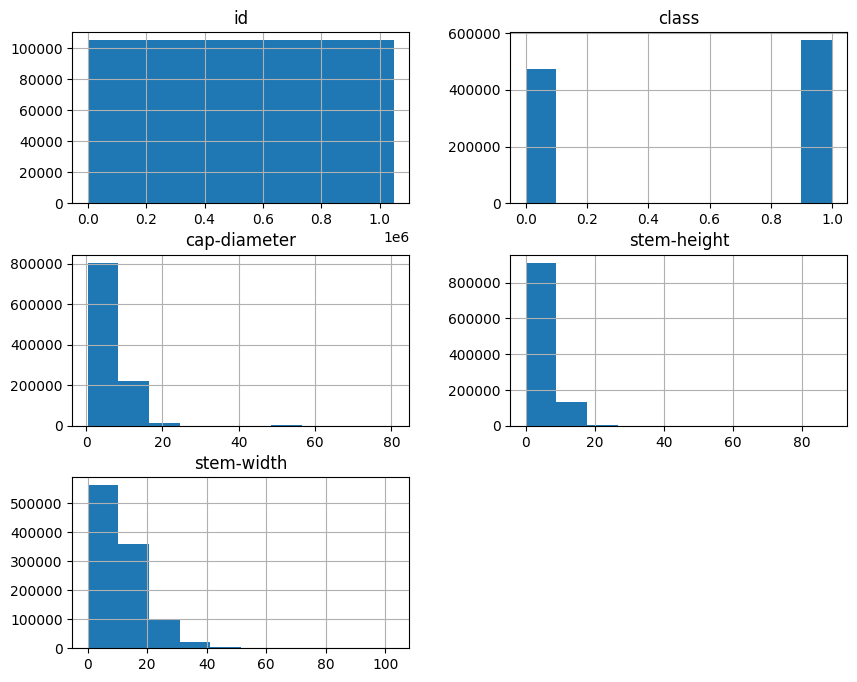

In [22]:
# Celula 20 - Verificação do split
print("Treino:", X_train.shape, "Teste:", X_test.shape)

df.hist(figsize=(10,8))
plt.show()
